<a href="https://colab.research.google.com/github/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/blob/main/Marcel's%20SYEP_Frontier_Technology_Institute_Sustainable_Energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#GitHub & CSV links
github_repo_url = "https://github.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy"
github_repo_url2 = "https://github.com/frontiertechinstitute/datasets/blob/main/Sustainable%20Energy%20Data/sustainable_energy.csv"
RAW_URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-05-26/energy_cleaned.csv"
Income_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/world-bank-income-groups.filtered%20(1990%20-%202010)%20-%20world-bank-income-groups.csv"
change_energy_consumption_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/change-energy-consumption.csv"
GDPPerCapital_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/GDP%20per%20capita%20(current%20US%24).csv"
GPD_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/8d6d7cd21aacc14fb0f3893c9206efa93b97b59c/Global_Economi_Indicators_Data.csv"

Now, let's update the `classify_income_group` function to use this loaded data. This function will now take both `country_name` and `year` to accurately assign an income group, as a country's income group can change over time.

### RAW DATA
- getting all the info from the already clean raw data that needs further cleaning to create a question.

### Useful Links
GitHub Links:  
- https://github.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy
- https://github.com/frontiertechinstitute/datasets/tree/main/Sustainable%20Energy%20Data

EXCEL/ GOOGLE SHEETS link:
- https://docs.google.com/spreadsheets/d/1kZM9rDKemBRJWe3LN_ooOuFAueEiNO47cbIxYA3evtg/edit?usp=sharing
- https://docs.google.com/spreadsheets/d/1357QsLQOwQhmujFc6_yFXavfhjqWL3wjl9AeHl8zgPk/edit?usp=sharing


Extra Data Sets Links:
- https://data.worldbank.org/
- https://ourworldindata.org/

(Data to preview as an explamle):
- https://ourworldindata.org/energy-production-consumption

- (GPD Data):
- https://data.worldbank.org/indicator/NY.GDP.MKTP.CD?end=2010&start=1990

(Income Groups Data):
- https://ourworldindata.org/world-bank-income-groups-explained#:~:text=Once%20GNI%20per%20capita%20is,others%20with%20populations%20over%2030%2C000.

### Research question:
***- How dose energy sources computation varies over the years across different countries with different income classifications ?***

In [3]:
import pandas as pd

raw_df = pd.read_csv(RAW_URL)
display(raw_df.head(5146)) # Preview the the dataset (can be accsess thorugh google sheets or EXCEL)

,country_name,country_code,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
0,Afghanistan,AFG,1990,NaN,5.000000,NaN,20.360110,34.61567,78.000000,0.0,...,9.661832e+03,0.49400,4.519325e+04,32.166878,3107.90970,NaN,0.0,0.0,NaN,NaN
1,Afghanistan,AFG,1991,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,9.229662e+03,0.49400,4.258417e+04,34.517311,3185.83125,NaN,0.0,0.0,NaN,NaN
2,Afghanistan,AFG,1992,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,8.012857e+03,0.49400,2.900446e+04,41.803092,3349.62180,NaN,0.0,0.0,NaN,NaN
3,Afghanistan,AFG,1993,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,9.402114e+03,0.49400,2.887722e+04,37.706436,3545.20215,NaN,0.0,0.0,NaN,NaN
4,Afghanistan,AFG,1994,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,9.444700e+03,0.49400,2.917647e+04,39.764867,3755.67255,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5141,West Bank and Gaza,WBG,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5142,West Bank and Gaza,WBG,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5143,West Bank and Gaza,WBG,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5144,West Bank and Gaza,WBG,2010,NaN,NaN,NaN,90.098370,94.13527,95.543853,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
raw_df.info(5146) #View column names, non-null counts, and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5271 entries, 0 to 5270
Data columns (total 52 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   country_name                                                       5271 non-null   object 
 1   country_code                                                       5271 non-null   object 
 2   yr                                                                 5271 non-null   int64  
 3   access_non_solid_fuel_rural_pop_pct                                197 non-null    float64
 4   access_non_solid_fuel_total_pop_pct                                630 non-null    float64
 5   access_non_solid_fuel_urban_pop_pct                                197 non-null    float64
 6   access_electricity_rural_pop_pct                                   696 non-null    float64
 7   access_electricity_total

In [5]:
raw_df.describe() #Get summary statistics for numeric columns

,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,biogas_consumption_terajoules,divisia_decomp_analysis_activity_component_index,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
count,5271.000000,197.000000,630.000000,197.000000,696.000000,696.000000,692.000000,4683.000000,4683.000000,2872.000000,...,4.534000e+03,4683.000000,4.637000e+03,4541.000000,4.683000e+03,3196.000000,4683.000000,4683.000000,1306.000000,1.263000e+03
mean,2000.000000,54.115327,60.208403,75.551069,63.946506,72.872716,84.577451,0.018907,4066.045067,1.430191,...,4.966429e+06,65.139508,7.647936e+06,21.245445,4.956911e+05,15.817747,0.031728,2686.193669,0.191752,1.568623e+04
std,6.055875,38.472578,34.742075,30.369027,37.242464,31.967909,23.318351,0.062921,28758.616649,0.791566,...,2.314921e+07,318.340461,3.624247e+07,29.955535,2.455813e+06,15.335802,0.171642,17094.627698,0.515589,7.105024e+04
min,1990.000000,5.000000,5.000000,5.000000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,1995.000000,13.000000,25.555280,70.000000,28.534595,48.858830,76.998348,0.000000,0.000000,1.025426,...,3.734481e+04,0.165250,5.529487e+04,0.000000,0.000000e+00,7.762815,0.000000,0.000000,0.001471,2.094871e+01
50%,2000.000000,53.429736,72.765372,95.000000,78.045428,88.229380,97.343039,0.000000,0.000000,1.273345,...,1.933980e+05,1.674800,2.636463e+05,2.487794,1.608312e+03,12.339609,0.000000,0.000000,0.013847,2.355756e+02
75%,2005.000000,95.000000,95.000000,95.000000,99.725000,99.955458,100.000000,0.000000,0.000000,1.629765,...,9.950604e+05,13.345000,1.414490e+06,39.807478,4.792682e+04,18.898634,0.000000,0.000000,0.123185,3.513872e+03
max,2010.000000,100.000000,100.000000,100.018099,100.000000,100.000000,100.000000,0.931991,615095.895200,11.648352,...,3.298342e+08,5066.765300,5.344336e+08,100.000000,3.150200e+07,213.043478,2.816079,250459.601000,4.252594,1.050023e+06


In [6]:
raw_df.isnull().sum() #Count missing values in each column

,0
country_name,0
country_code,0
yr,0
access_non_solid_fuel_rural_pop_pct,5074
access_non_solid_fuel_total_pop_pct,4641
access_non_solid_fuel_urban_pop_pct,5074
access_electricity_rural_pop_pct,4575
access_electricity_total_pop_pct,4575
access_electricity_urban_pop_pct,4579
biogas_consumption_tfec_pct,588


In [7]:
raw_df.duplicated().sum() #Count duplicate rows

np.int64(0)

In [8]:
raw_df["country_name"].unique() #View unique values in a column

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Caucasus and Central Asia', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Channel Islands', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba',
       'Curacao', 'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Eastern Asia (including Japan)',
       'Eastern Asia (not including Japan)', 'East

In [9]:
print(raw_df.columns.tolist())

['country_name', 'country_code', 'yr', 'access_non_solid_fuel_rural_pop_pct', 'access_non_solid_fuel_total_pop_pct', 'access_non_solid_fuel_urban_pop_pct', 'access_electricity_rural_pop_pct', 'access_electricity_total_pop_pct', 'access_electricity_urban_pop_pct', 'biogas_consumption_tfec_pct', 'biogas_consumption_terajoules', 'divisia_decomp_analysis_activity_component_index', 'divisia_decomp_analysis_energy_intensity_component_index', 'divisia_decomp_analysis_structure_component_index', 'energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp', 'energy_intensity_level_primary_energy_megajoules_per_usd_2005_ppp', 'energy_intensity_agricultural_sector_megajoules_per_usd_2005', 'energy_intensity_industrial_sector_megajoules_per_usd_2005', 'energy_intensity_other_sectors_megajoules_per_usd_2005', 'energy_savings_primary_energy_terajoules', 'final_to_primary_energy_ratio_pct', 'geothermal_energy_consumption_tfec_pct', 'geothermal_energy_consumption_terajoules', 'hydro_energy_consum

In [10]:
raw_df["country_name"].value_counts() # Count each unique value in a column

,count
country_name,
Afghanistan,21
Albania,21
Algeria,21
American Samoa,21
Andorra,21
...,...
Western Sahara,21
World,21
"Yemen, Rep.",21


In [11]:
# List of key numerical variables to analyze
key_variables = [
    'access_electricity_total_pop_pct',
    'access_electricity_rural_pop_pct',
    'access_electricity_urban_pop_pct',
    'renewable_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'wind_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_installed_capacity_gigawatts',
    'total_installed_generation_capacity_gigawatts',
    'energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp',
    'total_final_energy_consumption_tfec'
]

# Display summary statistics for each key variable
for col in key_variables:
    if col in raw_df.columns:
        print(f"\n--- Summary statistics for {col} ---")
        display(raw_df[col].describe())
    else:
        print(f"\n--- Column '{col}' not found in DataFrame ---")


--- Summary statistics for access_electricity_total_pop_pct ---


,access_electricity_total_pop_pct
count,696.000000
mean,72.872716
std,31.967909
min,0.100000
25%,48.858830
50%,88.229380
75%,99.955458
max,100.000000



--- Summary statistics for access_electricity_rural_pop_pct ---


,access_electricity_rural_pop_pct
count,696.000000
mean,63.946506
std,37.242464
min,0.100000
25%,28.534595
50%,78.045428
75%,99.725000
max,100.000000



--- Summary statistics for access_electricity_urban_pop_pct ---


...

,total_installed_generation_capacity_gigawatts
count,4683.000000
mean,65.139508
std,318.340461
min,0.000000
25%,0.165250
50%,1.674800
75%,13.345000
max,5066.765300



--- Summary statistics for energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp ---


,energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp
count,4102.000000
mean,8.544423
std,10.702171
min,0.122324
25%,3.928692
50%,5.536100
75%,9.269442
max,204.429924



--- Summary statistics for total_final_energy_consumption_tfec ---


,total_final_energy_consumption_tfec
count,4.534000e+03
mean,4.966429e+06
std,2.314921e+07
min,0.000000e+00
25%,3.734481e+04
50%,1.933980e+05
75%,9.950604e+05
max,3.298342e+08


### Further Cleaning
Want to answer One of of Two Questions:
- Do high income counties create a higher % of their engery from their renewable soruces than low income or mid income counties in 2000 vs 2010
(Develped vs underdevelped counties)


Or

- Which energy source gives the Unidted states the most total engery compostion Old renwable soruces like hydro vs. New renwable soruces like solar.2000 vs 2010
(old vs New renwable soruces)

### Finding High Income, Middle Income, & Low income countries & Upper-middle-income Countries & Lowerr-middle-income Countries







In [154]:
# Load the income group data
income_group_df = pd.read_csv(Income_URL)

# Rename columns for easier access and consistency
income_group_df = income_group_df.rename(columns={'Entity': 'country_name', 'Year': 'yr', "World Bank's income classification": 'income_group'})

# Drop columns that are not needed after renaming
income_group_df = income_group_df.drop(columns=['Code'], errors='ignore')

# Ensure 'yr' is integer type
income_group_df['yr'] = income_group_df['yr'].astype(int)

# Clean country names in income_group_df by stripping whitespace
income_group_df['country_name'] = income_group_df['country_name'].str.strip()

print("--- Income Group Data Preview ---")
display(income_group_df.head())

print("--- Income Group Data Info ---")
display(income_group_df.info())

print("--- Unique Income Groups in Loaded Data ---")
display(income_group_df['income_group'].unique())

--- Income Group Data Preview ---


,country_name,yr,income_group
0,Afghanistan,1990,Low-income countries
1,Afghanistan,1991,Low-income countries
2,Afghanistan,1992,Low-income countries
3,Afghanistan,1993,Low-income countries
4,Afghanistan,1994,Low-income countries


--- Income Group Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4382 entries, 0 to 4381
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_name  4382 non-null   object
 1   yr            4382 non-null   int64 
 2   income_group  4382 non-null   object
dtypes: int64(1), object(2)
memory usage: 102.8+ KB


None

--- Unique Income Groups in Loaded Data ---


array(['Low-income countries', 'Lower-middle-income countries',
       'Upper-middle-income countries', 'High-income countries'],
      dtype=object)

In [14]:
# Merge income_group_df into raw_df to add the 'income_group' column
# Use a left merge to keep all entries from raw_df and add corresponding income groups
print(f"Shape of raw_df before merge: {raw_df.shape}")
raw_df = pd.merge(raw_df, income_group_df, on=['country_name', 'yr'], how='left')
print(f"Shape of raw_df after merge: {raw_df.shape}")

print("--- Sample of raw_df after merging with income_group_df ---")
display(raw_df[['country_name', 'yr', 'income_group']].head())

print("--- Distribution of Income Groups after Merge ---")
display(raw_df['income_group'].value_counts(dropna=False))

Shape of raw_df before merge: (3528, 52)
Shape of raw_df after merge: (3528, 53)
--- Sample of raw_df after merging with income_group_df ---


,country_name,yr,income_group
0,Afghanistan,1990,Low-income countries
1,Afghanistan,1991,Low-income countries
2,Afghanistan,1992,Low-income countries
3,Afghanistan,1993,Low-income countries
4,Afghanistan,1994,Low-income countries


--- Distribution of Income Groups after Merge ---


,count
income_group,
Low-income countries,1025
Lower-middle-income countries,948
High-income countries,740
Upper-middle-income countries,590
NaN,225


In [15]:
print("--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---")
display(raw_df['income_group'].value_counts())

us_income_group = raw_df[raw_df['country_name'] == 'United States']['income_group'].unique()
if len(us_income_group) > 0:
    print(f"The United States is classified as: {us_income_group[0]}")
else:
    print("The United States is not found or not classified in the current data.")

india_income_group = raw_df[raw_df['country_name'] == 'India']['income_group'].unique()
if len(india_income_group) > 0:
    print(f"India is classified as: {india_income_group[0]}")
else:
    print("India is not found or not classified in the current data.")

--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---


,count
income_group,
Low-income countries,1025
Lower-middle-income countries,948
High-income countries,740
Upper-middle-income countries,590


The United States is classified as: High-income countries
India is classified as: Low-income countries


In [187]:
def classify_income_group_from_df(country_name, year, income_df):
    country_year_data = income_df[(income_df['country_name'] == country_name) & (income_df['yr'] == year)]

    if not country_year_data.empty:
        detailed_group = country_year_data['income_group'].iloc[0]

        if 'High-income' in detailed_group:
            return 'High Income Countries'
        elif 'Lower-middle-income' in detailed_group:
            return 'Lower-middle-income Countries'
        elif 'Upper-middle-income' in detailed_group:
            return 'Upper-middle-income Countries'
        elif 'Low-income' in detailed_group:
            return 'Low Income Countries'
        else:
            return 'Not Classified'
    else:
        return 'Not Classified'

In [190]:
print("--- Distribution of Income Groups after DataFrame-based Classification ---")
display(income_group_df['income_group'].value_counts())

--- Distribution of Income Groups after DataFrame-based Classification ---


,count
income_group,
Lower-middle-income countries,1228
Low-income countries,1184
High-income countries,1162
Upper-middle-income countries,808


In [194]:
import pandas as pd

# Apply the classification function using income_group_df and directly update the 'income_group' column

def diagnostic_classify(row):
    country = row['country_name']
    year = row['yr']
    return classify_income_group_from_df(country, year, income_group_df)

income_group_df['income_group'] = income_group_df.apply(diagnostic_classify, axis=1)

print("--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---")
display(income_group_df['income_group'].value_counts())

print("--- Sample of Income Group Classification ---")
display(income_group_df[['country_name', 'yr', 'income_group']].sample(10))

--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---


,count
income_group,
Not Classified,2346
Lower-middle-income Countries,1228
Upper-middle-income Countries,808


--- Sample of Income Group Classification ---


,country_name,yr,income_group
1194,Egypt,2007,Lower-middle-income Countries
1845,Iceland,2005,Not Classified
1449,French Southern Territories,1992,Not Classified
3513,Senegal,2001,Not Classified
2646,Moldova,1995,Lower-middle-income Countries
3935,Tanzania,2009,Not Classified
2492,Mali,2006,Not Classified
603,Bulgaria,2010,Upper-middle-income Countries
3452,San Marino,2003,Not Classified
1063,Denmark,1991,Not Classified


In [197]:
# Drop any Income countries that are not classified through the Raw Data set
print(f"Raw data shape before dropping 'Not Classified' rows: {income_group_df.shape}")
income_group_df = income_group_df[income_group_df['income_group'] != 'Not Classified'].copy()
print(f"Raw data after dropping 'Not Classified' rows: {income_group_df.shape}")

Raw data shape before dropping 'Not Classified' rows: (2036, 3)
Raw data after dropping 'Not Classified' rows: (2036, 3)


In [200]:
years_to_analyze = [1990, 2000, 2010]
filtered_years_df = final_combined_df_with_gdp[final_combined_df_with_gdp['yr'].isin(years_to_analyze)].copy()

# Filter for classified income groups only (excluding 'Not Classified')
# This step is technically redundant now that 'Not Classified' rows have been dropped from raw_df,
# but it's kept for robustness if raw_df were to be reloaded without re-classification.
classified_income_df = filtered_years_df[filtered_years_df['income_group'] != 'Not Classified']

# Group by year and income_group and calculate the mean of renewable energy consumption percentage
renewable_energy_by_income_group = classified_income_df.groupby(['yr', 'income_group'])['renewable_energy_consumption_tfec_pct'].mean().unstack()

print("Average Renewable Energy Consumption (TFEC %) by Income Group for 1990, 2000 and 2010:")
display(renewable_energy_by_income_group)

Average Renewable Energy Consumption (TFEC %) by Income Group for 1990, 2000 and 2010:


income_group,High Income Countries,Low Income Countries,Lower-middle-income Countries,Upper-middle-income Countries
yr,,,,
1990,8.529072,72.939753,24.574908,20.482264
2000,8.397947,76.237694,17.962144,20.217069
2010,10.954435,85.222972,34.145009,20.605738


In [201]:
years_to_analyze = [1990, 2000, 2010]
filtered_years_df = final_combined_df_with_gdp[final_combined_df_with_gdp['yr'].isin(years_to_analyze)].copy()

# Filter for classified income groups only (excluding 'Not Classified')
classified_income_df = filtered_years_df[filtered_years_df['income_group'] != 'Not Classified']

# Group by year & income_group & calculate the mean of renewable energy
# consumption percentage
renewable_energy_by_income_group = classified_income_df.groupby(['yr', 'income_group'])['renewable_energy_consumption_tfec_pct'].mean().unstack()

print("Average Renewable Energy Consumption (TFEC %) by Income Group for 2000 and 2010:")
display(renewable_energy_by_income_group)

Average Renewable Energy Consumption (TFEC %) by Income Group for 2000 and 2010:


income_group,High Income Countries,Low Income Countries,Lower-middle-income Countries,Upper-middle-income Countries
yr,,,,
1990,8.529072,72.939753,24.574908,20.482264
2000,8.397947,76.237694,17.962144,20.217069
2010,10.954435,85.222972,34.145009,20.605738


### All Classified Countries by Income Group

In [204]:
high_income_countries_full = income_group_df[income_group_df['income_group'] == 'High Income Countries']['country_name'].unique().tolist()
middle_income_countries_full = income_group_df[income_group_df['income_group'].isin(['Lower-middle-income Countries', 'Upper-middle-income Countries'])]['country_name'].unique().tolist()
low_income_countries_full = income_group_df[income_group_df['income_group'] == 'Low Income Countries']['country_name'].unique().tolist()

# Create a dictionary to hold the lists, using pd.Series to handle unequal lengths
data = {
    'High Income Countries': pd.Series(high_income_countries_full),
    'upper-middle-income Countries': pd.Series(middle_income_countries_full),
    'Middle Income Countries': pd.Series(middle_income_countries_full),
    'lower-middle-income Countries': pd.Series(middle_income_countries_full),
    'Low Income Countries': pd.Series(low_income_countries_full)
}

# Create a DataFrame from the dictionary
all_classified_countries_df = pd.DataFrame(data)

print("\n--- All Classified Countries by Income Group ---")
display(all_classified_countries_df)


--- All Classified Countries by Income Group ---


,High Income Countries,upper-middle-income Countries,Middle Income Countries,lower-middle-income Countries,Low Income Countries
0,NaN,Albania,Albania,Albania,NaN
1,NaN,Algeria,Algeria,Algeria,NaN
2,NaN,American Samoa,American Samoa,American Samoa,NaN
3,NaN,Angola,Angola,Angola,NaN
4,NaN,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,NaN
5,NaN,Argentina,Argentina,Argentina,NaN
6,NaN,Armenia,Armenia,Armenia,NaN
7,NaN,Aruba,Aruba,Aruba,NaN
8,NaN,Azerbaijan,Azerbaijan,Azerbaijan,NaN
9,NaN,Bahrain,Bahrain,Bahrain,NaN


### Graph From Raw Data

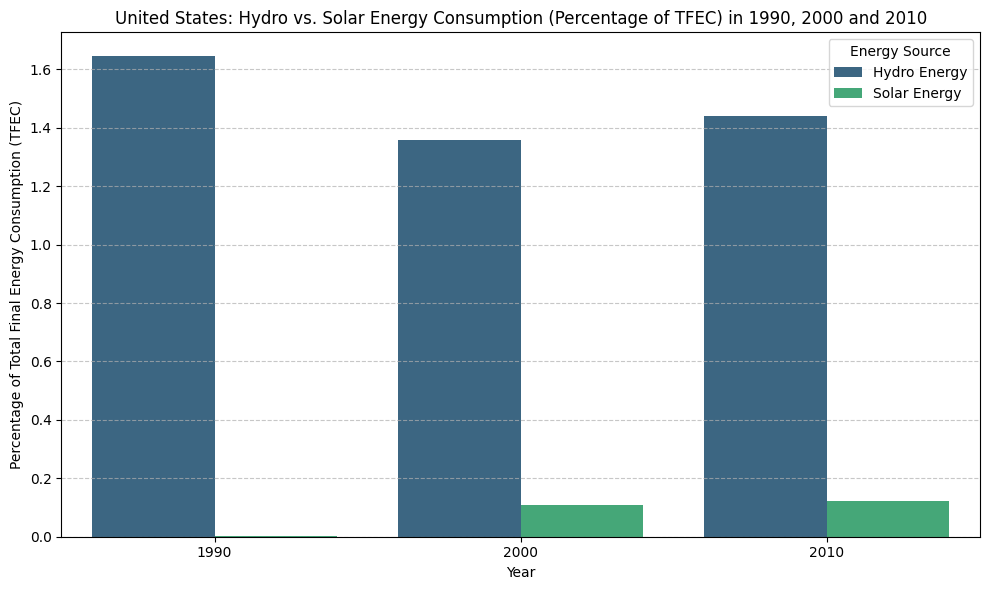

In [26]:
#Make the Plot for the data that I want to anaylze
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for United States and years 1990, 2000, 2010
us_energy_data = raw_df[
    (raw_df['country_name'] == 'United States') &
    (raw_df['yr'].isin([1990, 2000, 2010]))
][['yr', 'hydro_energy_consumption_tfec_pct', 'solar_energy_consumption_tfec_pct']]

# Melt the DataFrame for easier plotting
us_energy_melted = us_energy_data.melt(
    id_vars=['yr'],
    value_vars=['hydro_energy_consumption_tfec_pct', 'solar_energy_consumption_tfec_pct'],
    var_name='energy_source',
    value_name='percentage_tfec'
)

# Map column names for better readability on the plot
us_energy_melted['energy_source'] = us_energy_melted['energy_source'].map({
    'hydro_energy_consumption_tfec_pct': 'Hydro Energy',
    'solar_energy_consumption_tfec_pct': 'Solar Energy'
})

# Create the bar plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(
    x='yr',
    y='percentage_tfec',
    hue='energy_source',
    data=us_energy_melted,
    palette='viridis'
)

plt.title('United States: Hydro vs. Solar Energy Consumption (Percentage of TFEC) in 1990, 2000 and 2010')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Final Energy Consumption (TFEC)')
plt.legend(title='Energy Source')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Row/Column Droping

In [31]:
#Drop the cloums / rows that im not focusing on

columns_to_drop = ['access_electricity_total_pop_pct', 'access_electricity_rural_pop_pct', 'access_electricity_urban_pop_pct', 'renewable_energy_installed_capacity_gigawatts', 'total_installed_generation_capacity_gigawatts']

In [32]:
raw_df = raw_df.drop(columns=columns_to_drop, errors='ignore')

In [33]:
# List to store indices of rows to be dropped (if any)
rows_to_drop = []

In [205]:
selected_columns = [
    'country_name',
    'yr',
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Filter the DataFrame for the selected countries and columns
# Assuming 'final_selected_countries' list from cell e43c3420 is the intended filter
filtered_energy_df = raw_df[raw_df['country_name'].isin(final_selected_countries)][selected_columns]

# Display the first few rows of the new DataFrame
display(filtered_energy_df.head(63))

,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,total_final_energy_consumption_tfec
0,Afghanistan,1990,NaN,0.0,0.000000,10.195503,9.661832e+03
1,Afghanistan,1991,NaN,0.0,0.000000,9.545578,9.229662e+03
2,Afghanistan,1992,NaN,0.0,0.000000,8.981214,8.012857e+03
3,Afghanistan,1993,NaN,0.0,0.000000,17.009797,9.402114e+03
4,Afghanistan,1994,NaN,NaN,NaN,16.760214,9.444700e+03
5,Afghanistan,1995,NaN,NaN,NaN,16.328298,9.528358e+03
6,Afghanistan,1996,NaN,NaN,NaN,13.798788,1.130921e+04
7,Afghanistan,1997,NaN,NaN,NaN,13.750519,1.142793e+04
8,Afghanistan,1998,NaN,NaN,NaN,13.002026,1.224226e+04
9,Afghanistan,1999,NaN,NaN,NaN,15.857293,1.027644e+04


## Convert columns to numeric, coercing non-numeric values to NaN

In [35]:
# Create a copy of the DataFrame to apply numeric conversion
filtered_energy_df_numeric = filtered_energy_df.copy()

# Columns to convert to numeric
energy_cols_to_convert = [
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct'
]

for col in energy_cols_to_convert:
    if col in filtered_energy_df_numeric.columns:
        filtered_energy_df_numeric[col] = pd.to_numeric(filtered_energy_df_numeric[col], errors='coerce')

# Display info to confirm data types in the new DataFrame
print("Data types after conversion in filtered_energy_df_numeric:")
display(filtered_energy_df_numeric.info())

Data types after conversion in filtered_energy_df_numeric:
<class 'pandas.core.frame.DataFrame'>
Index: 63 entries, 0 to 3338
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country_name                            63 non-null     object 
 1   yr                                      63 non-null     int64  
 2   wind_energy_consumption_tfec_pct        42 non-null     float64
 3   geothermal_energy_consumption_tfec_pct  46 non-null     float64
 4   solar_energy_consumption_tfec_pct       46 non-null     float64
 5   hydro_energy_consumption_tfec_pct       62 non-null     float64
 6   total_final_energy_consumption_tfec     62 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 3.9+ KB


None

In [169]:
print("Missing values in filtered_energy_df_numeric after conversion:")
display(filtered_energy_df_numeric.isnull().sum())

Missing values in filtered_energy_df_numeric after conversion:


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,21
geothermal_energy_consumption_tfec_pct,17
solar_energy_consumption_tfec_pct,17
hydro_energy_consumption_tfec_pct,1
total_final_energy_consumption_tfec,1


## Creating a DataFrame with a Broader Set of Countries

To provide a more comprehensive dataset for analysis, we will create a single DataFrame that combines a curated list of countries, carefully categorized into High, Middle, and Low-income groups.

This selection ensures a balanced representation across different economic classifications for our analysis:

*   **High Income Countries:** United States, Australia, Japan, Spain, France
*   **Middle Income Countries:** India, Brazil, Mexico, South Africa
*   **Low Income Countries:** Afghanistan, Ethiopia, Chad, Niger

We will then apply the necessary data filtering, numeric conversion, and missing value imputation steps to this combined dataset to prepare it for further analysis.

In [137]:
import pandas as pd

# Define the comprehensive list of countries
# Updated to include 'Canada', 'Egypt', and 'Madagascar' as per request
final_selected_countries = [
    'Afghanistan', 'Australia', 'Brazil', 'Burundi', 'Canada', 'Chad', 'China',
    'Egypt', 'Ethiopia', 'France', 'Germany', 'India', 'Indonesia', 'Japan',
    'Madagascar', 'Malawi', 'Mexico', 'Niger', 'South Africa', 'Spain', 'Turkey',
    'United States'
]

# Use the same selected columns as before for energy consumption data
final_selected_columns = [
    'country_name',
    'yr',
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Filter the raw_df for this comprehensive set of countries and columns
final_combined_energy_df = raw_df[raw_df['country_name'].isin(final_selected_countries)][final_selected_columns].copy()

# Create a copy for numeric conversion and imputation
final_combined_energy_df_numeric = final_combined_energy_df.copy()

# Columns to convert to numeric
energy_cols_to_convert_final = [
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Convert to numeric, coercing non-numeric values to NaN
for col in energy_cols_to_convert_final:
    if col in final_combined_energy_df_numeric.columns:
        final_combined_energy_df_numeric[col] = pd.to_numeric(final_combined_energy_df_numeric[col], errors='coerce')

# Fill missing values using the same imputation method:
# 1. Country-specific median
# 2. Overall column median (if any NaNs remain)
for col in energy_cols_to_convert_final:
    if col in final_combined_energy_df_numeric.columns:
        final_combined_energy_df_numeric[col] = final_combined_energy_df_numeric.groupby('country_name')[col].transform(lambda x: x.fillna(x.median()))
        if final_combined_energy_df_numeric[col].isnull().any():
            global_median = final_combined_energy_df_numeric[col].median()
            final_combined_energy_df_numeric[col] = final_combined_energy_df_numeric[col].fillna(global_median)

# Apply the previously defined classify_income_group_from_df function
# This function uses income_group_df (loaded from Income_URL) for classification
final_combined_energy_df_numeric['income_group'] = final_combined_energy_df_numeric.apply(
    lambda row: classify_income_group_from_df(row['country_name'], row['yr'], income_group_df), axis=1
)

print("Final Combined DataFrame with imputed values and Income Groups:")
display(final_combined_energy_df_numeric.head())

print("Missing values in final_combined_energy_df_numeric after imputation:")
display(final_combined_energy_df_numeric.isnull().sum())

DEBUG: classify_income_group_from_df called for Brazil (Year: 1990)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Brazil' and year=1990 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-middle-income countries'
DEBUG:   Condition 1 ('High-income' in detailed_group): False
DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): True
DEBUG:   Condition 3 ('Low-income' in detailed_group): False
DEBUG: classify_income_group_from_df called for Brazil (Year: 2000)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Brazil' and year=2000 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-middle-income countries'
DEBUG:   Condition 1 ('High-income' in detailed_group): False
DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): True
DEBUG:   Condition 3 ('Low-income' in detailed_group): Fa

,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group
0,Afghanistan,1990,0.010637,0.0,0.0,10.195503,42.362380,9661.83210,Low Income
1,Afghanistan,1991,0.010637,0.0,0.0,9.545578,44.062889,9229.66245,Low Income
2,Afghanistan,1992,0.010637,0.0,0.0,8.981214,50.784306,8012.85660,Low Income
3,Afghanistan,1993,0.010637,0.0,0.0,17.009797,54.716233,9402.11415,Low Income
4,Afghanistan,1994,0.010637,0.0,0.0,16.760214,56.525081,9444.70035,Low Income


Missing values in final_combined_energy_df_numeric after imputation:


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0


In [133]:
# Re-run GDP data processing to include the newly selected countries
import pandas as pd

gdpPerCapital_df_raw = pd.read_csv(GDPPerCapital_URL)

# Strip whitespace from 'Series Name' to ensure accurate matching
gdpPerCapital_df_raw['Series Name'] = gdpPerCapital_df_raw['Series Name'].str.strip()

# Filter for the relevant series: GDP per capita (current US$)
gdpPerCapital_df_raw_gdp_only = gdpPerCapital_df_raw[gdpPerCapital_df_raw['Series Name'] == 'GDP per capita (current US$)'].copy()

# Identify year columns (e.g., '1990 [YR1990]', '1991 [YR1991]', etc.)
year_columns = [col for col in gdpPerCapital_df_raw_gdp_only.columns if '[YR' in col]

# Melt the DataFrame to transform year columns into rows
gdpPerCapital_df = gdpPerCapital_df_raw_gdp_only.melt(
    id_vars=['Country Name', 'Country Code'], # Keep country identifiers
    value_vars=year_columns,
    var_name='yr_full',
    value_name='gdp_usd'
)

# Extract the numeric year from 'yr_full'
gdpPerCapital_df['yr'] = gdpPerCapital_df['yr_full'].apply(lambda x: int(x.split(' ')[0]))

# Rename 'Country Name' for consistency with energy dataframe
gdpPerCapital_df = gdpPerCapital_df.rename(columns={'Country Name': 'country_name'})

# Apply the same country name mapping as used for raw_df
# (Copied from cell 585b5eb5 for self-containment of this processing step)
country_name_mapping = {
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Russian Federation': 'Russia',
    'Slovak Republic': 'Slovakia',
    'Taiwan, China': 'Taiwan',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Hong Kong SAR, China': 'Hong Kong',
    'Bahamas, The': 'Bahamas'
}
gdpPerCapital_df['country_name'] = gdpPerCapital_df['country_name'].replace(country_name_mapping)

# Filter out non-country entities from gdpPerCapital_df as well
# (Copied from cell 585b5eb5 for self-containment of this processing step)
non_country_entities_to_filter = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Channel Islands', 'American Samoa', 'Andorra', 'Aruba', 'Bermuda',
    'British Virgin Islands', 'Cayman Islands', 'Cook Islands', 'Curacao',
    'Dominica', 'Faeroe Islands', 'Falkland Islands', 'French Guyana',
    'French Polynesia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam',
    'Isle of Man', 'Kiribati', 'Liechtenstein', 'Marshall Islands',
    'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco', 'Montserrat',
    'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands', 'Palau',
    'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire"
]
gdpPerCapital_df = gdpPerCapital_df[~gdpPerCapital_df['country_name'].isin(non_country_entities_to_filter)].copy()

# Select final columns and convert 'gdp_usd' to numeric
gdpPerCapital_df = gdpPerCapital_df[['country_name', 'yr', 'gdp_usd']].copy()
gdpPerCapital_df['gdp_usd'] = pd.to_numeric(gdpPerCapital_df['gdp_usd'], errors='coerce')

# Drop rows where GDP is NaN after conversion or if country_name is missing
gdpPerCapital_df.dropna(subset=['gdp_usd', 'country_name'], inplace=True)

# Filter for years 1990, 2000, 2010 as per problem description context
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['yr'].isin([1990, 2000, 2010])].copy()

# Filter gdpPerCapital_df to include only the final_selected_countries to match the energy dataframe
# This list was updated in e43c3420, so use the global variable 'final_selected_countries'
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['country_name'].isin(final_selected_countries)].copy()


print("--- GDP Data Preview ---")
display(gdpPerCapital_df.head())

print("--- GDP Data Info ---")
display(gdpPerCapital_df.info())

print("--- Missing values in GDP Data ---")
display(gdpPerCapital_df.isnull().sum())

--- GDP Data Preview ---


,country_name,yr,gdp_usd
10,Australia,1990,18273.561530
26,Brazil,1990,2581.141874
31,Burundi,1990,202.629446
38,Chad,1990,290.599045
41,China,1990,318.503354


--- GDP Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 53 entries, 10 to 4976
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  53 non-null     object 
 1   yr            53 non-null     int64  
 2   gdp_usd       53 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ KB


None

--- Missing values in GDP Data ---


,0
country_name,0
yr,0
gdp_usd,0


In [134]:
# Merge final_combined_energy_df_numeric with gdpPerCapital_df to create final_combined_df_with_gdp
# We'll use a left merge to keep all energy data and add GDP information where available
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

# Impute missing gdp_usd values
# 1. Fill with country-specific median
final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp.groupby('country_name')['gdp_usd'].transform(lambda x: x.fillna(x.median()))

# 2. Fill any remaining NaNs with the overall median
if final_combined_df_with_gdp['gdpPerCapital_usd'].isnull().any():
    global_gdp_median = final_combined_df_with_gdp['gdpPerCapital_usd'].median()
    final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp['gdpPerCapital_usd'].fillna(global_gdp_median)

print(f"Shape after merging with GDP data: {final_combined_df_with_gdp.shape}")
print("--- Sample of merged DataFrame with GDP ---")
display(final_combined_df_with_gdp.head())

print("--- Missing values after GDP merge and imputation ---")
display(final_combined_df_with_gdp.isnull().sum())

Shape after merging with GDP data: (399, 11)
--- Sample of merged DataFrame with GDP ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
0,Afghanistan,1990,0.007236,0.0,0.0,10.195503,42.362380,9661.83210,Low Income,NaN,367.776248
1,Afghanistan,1991,0.007236,0.0,0.0,9.545578,44.062889,9229.66245,Low Income,NaN,367.776248
2,Afghanistan,1992,0.007236,0.0,0.0,8.981214,50.784306,8012.85660,Low Income,NaN,367.776248
3,Afghanistan,1993,0.007236,0.0,0.0,17.009797,54.716233,9402.11415,Low Income,NaN,367.776248
4,Afghanistan,1994,0.007236,0.0,0.0,16.760214,56.525081,9444.70035,Low Income,NaN,367.776248


--- Missing values after GDP merge and imputation ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,346


In [156]:
# Re-run GDP data processing to include the newly selected countries
import pandas as pd

gdpPerCapital_df_raw = pd.read_csv(GDPPerCapital_URL)

# Strip whitespace from 'Series Name' to ensure accurate matching
gdpPerCapital_df_raw['Series Name'] = gdpPerCapital_df_raw['Series Name'].str.strip()

# Filter for the relevant series: GDP per capita (current US$)
gdpPerCapital_df_raw_gdp_only = gdpPerCapital_df_raw[gdpPerCapital_df_raw['Series Name'] == 'GDP per capita (current US$)'].copy()

# Identify year columns (e.g., '1990 [YR1990]', '1991 [YR1991]', etc.)
year_columns = [col for col in gdpPerCapital_df_raw_gdp_only.columns if '[YR' in col]

# Melt the DataFrame to transform year columns into rows
gdpPerCapital_df = gdpPerCapital_df_raw_gdp_only.melt(
    id_vars=['Country Name', 'Country Code'], # Keep country identifiers
    value_vars=year_columns,
    var_name='yr_full',
    value_name='gdp_usd'
)

# Extract the numeric year from 'yr_full'
gdpPerCapital_df['yr'] = gdpPerCapital_df['yr_full'].apply(lambda x: int(x.split(' ')[0]))

# Rename 'Country Name' for consistency with energy dataframe
gdpPerCapital_df = gdpPerCapital_df.rename(columns={'Country Name': 'country_name'})

# Apply the same country name mapping as used for raw_df
# (Copied from cell 585b5eb5 for self-containment of this processing step)
country_name_mapping = {
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Russian Federation': 'Russia',
    'Slovak Republic': 'Slovakia',
    'Taiwan, China': 'Taiwan',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Hong Kong SAR, China': 'Hong Kong',
    'Bahamas, The': 'Bahamas'
}
gdpPerCapital_df['country_name'] = gdpPerCapital_df['country_name'].replace(country_name_mapping)

# Filter out non-country entities from gdpPerCapital_df as well
# (Copied from cell 585b5eb5 for self-containment of this processing step)
non_country_entities_to_filter = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Channel Islands', 'American Samoa', 'Andorra', 'Aruba', 'Bermuda',
    'British Virgin Islands', 'Cayman Islands', 'Cook Islands', 'Curacao',
    'Dominica', 'Faeroe Islands', 'Falkland Islands', 'French Guyana',
    'French Polynesia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam',
    'Isle of Man', 'Kiribati', 'Liechtenstein', 'Marshall Islands',
    'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco', 'Montserrat',
    'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands', 'Palau',
    'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire"
]
gdpPerCapital_df = gdpPerCapital_df[~gdpPerCapital_df['country_name'].isin(non_country_entities_to_filter)].copy()

# Select final columns and convert 'gdp_usd' to numeric
gdpPerCapital_df = gdpPerCapital_df[['country_name', 'yr', 'gdp_usd']].copy()
gdpPerCapital_df['gdp_usd'] = pd.to_numeric(gdpPerCapital_df['gdp_usd'], errors='coerce')

# Drop rows where GDP is NaN after conversion or if country_name is missing
gdpPerCapital_df.dropna(subset=['gdp_usd', 'country_name'], inplace=True)

# Filter for years 1990, 2000, 2010 as per problem description context
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['yr'].isin([1990, 2000, 2010])].copy()

# Filter gdpPerCapital_df to include only the final_selected_countries to match the energy dataframe
# This list was updated in e43c3420, so use the global variable 'final_selected_countries'
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['country_name'].isin(final_selected_countries)].copy()


print("--- GDP Data Preview ---")
display(gdpPerCapital_df.head())

print("--- GDP Data Info ---")
display(gdpPerCapital_df.info())

print("--- Missing values in GDP Data ---")
display(gdpPerCapital_df.isnull().sum())

--- GDP Data Preview ---


,country_name,yr,gdp_usd
10,Australia,1990,18273.561530
26,Brazil,1990,2581.141874
31,Burundi,1990,202.629446
35,Canada,1990,21525.861140
38,Chad,1990,290.599045


--- GDP Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 10 to 4976
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  62 non-null     object 
 1   yr            62 non-null     int64  
 2   gdp_usd       62 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.9+ KB


None

--- Missing values in GDP Data ---


,0
country_name,0
yr,0
gdp_usd,0


In [157]:
# Merge final_combined_energy_df_numeric with gdpPerCapital_df to create final_combined_df_with_gdp
# We'll use a left merge to keep all energy data and add GDP information where available
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

# Impute missing gdp_usd values
# 1. Fill with country-specific median
final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp.groupby('country_name')['gdp_usd'].transform(lambda x: x.fillna(x.median()))

# 2. Fill any remaining NaNs with the overall median
if final_combined_df_with_gdp['gdpPerCapital_usd'].isnull().any():
    global_gdp_median = final_combined_df_with_gdp['gdpPerCapital_usd'].median()
    final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp['gdpPerCapital_usd'].fillna(global_gdp_median)

print(f"Shape after merging with GDP data: {final_combined_df_with_gdp.shape}")
print("--- Sample of merged DataFrame with GDP ---")
display(final_combined_df_with_gdp.head())

print("--- Missing values after GDP merge and imputation ---")
display(final_combined_df_with_gdp.isnull().sum())

Shape after merging with GDP data: (462, 11)
--- Sample of merged DataFrame with GDP ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
0,Afghanistan,1990,0.010637,0.0,0.0,10.195503,42.362380,9661.83210,Low Income Countries,NaN,367.776248
1,Afghanistan,1991,0.010637,0.0,0.0,9.545578,44.062889,9229.66245,Low Income Countries,NaN,367.776248
2,Afghanistan,1992,0.010637,0.0,0.0,8.981214,50.784306,8012.85660,Low Income Countries,NaN,367.776248
3,Afghanistan,1993,0.010637,0.0,0.0,17.009797,54.716233,9402.11415,Low Income Countries,NaN,367.776248
4,Afghanistan,1994,0.010637,0.0,0.0,16.760214,56.525081,9444.70035,Low Income Countries,NaN,367.776248


--- Missing values after GDP merge and imputation ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,400


In [62]:
print("--- Direct test of classify_income_group_from_df for problematic countries (Year 2000) ---")

problematic_countries = {
    'India': 'Middle Income',
    'Brazil': 'Middle Income',
    'Mexico': 'Middle Income',
    'South Africa': 'Middle Income'
}

check_year = 2000

for country, expected_group in problematic_countries.items():
    classified_group = classify_income_group_from_df(country, check_year, income_group_df)
    status = "CORRECT" if classified_group == expected_group else f"INCORRECT (Function returned: {classified_group})"
    print(f"  {country} (Expected: {expected_group}): {status}")

--- Direct test of classify_income_group_from_df for problematic countries (Year 2000) ---
  India (Expected: Middle Income): INCORRECT (Function returned: Low Income)
DEBUG: classify_income_group_from_df called for Brazil (Year: 2000)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Brazil' and year=2000 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-middle-income countries'
DEBUG:   Condition 1 ('High-income' in detailed_group): False
DEBUG:   Condition 2 ('middle-income' in detailed_group.lower()): True
DEBUG:   Condition 3 ('Low-income' in detailed_group): False
  Brazil (Expected: Middle Income): CORRECT
DEBUG: classify_income_group_from_df called for Mexico (Year: 2000)
DEBUG: Type of country_name: <class 'str'>, Type of year: <class 'int'>)
DEBUG: Looking for country_name='Mexico' and year=2000 in income_df
DEBUG: Inside classify_income_group_from_df. Found detailed_group: 'Upper-mid

In [158]:
print(final_combined_energy_df_numeric.columns.tolist())

['country_name', 'yr', 'wind_energy_consumption_tfec_pct', 'geothermal_energy_consumption_tfec_pct', 'solar_energy_consumption_tfec_pct', 'hydro_energy_consumption_tfec_pct', 'renewable_energy_consumption_tfec_pct', 'total_final_energy_consumption_tfec', 'income_group']


### Hypothesis Test: ANOVA for Renewable Energy Consumption WITHIN Income Groups

We will perform ANOVA tests to determine if there are significant differences in `renewable_energy_consumption_tfec_pct` among countries *within* each income group (High, Middle, and Low).

In [69]:
from scipy.stats import f_oneway

# --- ANOVA for High Income Countries ---
print("\n--- ANOVA for Renewable Energy Consumption in High Income Countries ---")
high_income_df = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'High Income']

high_income_country_groups = []
for country in high_income_df['country_name'].unique():
    high_income_country_groups.append(high_income_df[high_income_df['country_name'] == country]['renewable_energy_consumption_tfec_pct'].dropna())

if all(len(g) > 0 for g in high_income_country_groups) and len(high_income_country_groups) > 1:
    f_stat_high, p_val_high = f_oneway(*high_income_country_groups)
    print(f"F-statistic (High Income): {f_stat_high:.2f}")
    # Display p-value with higher precision in scientific notation
    print(f"P-value (High Income): {p_val_high:.10e}")
    if p_val_high < 0.05:
        print(f"Conclusion: Significant difference (p={p_val_high:.10e}) in renewable energy consumption among High Income countries.")
    else:
        print(f"Conclusion: No significant difference (p={p_val_high:.10e}) in renewable energy consumption among High Income countries.")
else:
    print("Not enough data to perform ANOVA for High Income countries.")

# --- ANOVA for Middle Income Countries ---
print("\n--- ANOVA for Renewable Energy Consumption in Middle Income Countries ---")
middle_income_df = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'Middle Income']

middle_income_country_groups = []
for country in middle_income_df['country_name'].unique():
    middle_income_country_groups.append(middle_income_df[middle_income_df['country_name'] == country]['renewable_energy_consumption_tfec_pct'].dropna())

if all(len(g) > 0 for g in middle_income_country_groups) and len(middle_income_country_groups) > 1:
    f_stat_middle, p_val_middle = f_oneway(*middle_income_country_groups)
    print(f"F-statistic (Middle Income): {f_stat_middle:.2f}")
    # Display p-value with higher precision in scientific notation
    print(f"P-value (Middle Income): {p_val_middle:.10e}")
    if p_val_middle < 0.05:
        print(f"Conclusion: Significant difference (p={p_val_middle:.10e}) in renewable energy consumption among Middle Income countries.")
    else:
        print(f"Conclusion: No significant difference (p={p_val_middle:.10e}) in renewable energy consumption among Middle Income countries.")
else:
    print("Not enough data to perform ANOVA for Middle Income countries.")

# --- ANOVA for Low Income Countries ---
print("\n--- ANOVA for Renewable Energy Consumption in Low Income Countries ---")
low_income_df = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'Low Income']

low_income_country_groups = []
for country in low_income_df['country_name'].unique():
    low_income_country_groups.append(low_income_df[low_income_df['country_name'] == country]['renewable_energy_consumption_tfec_pct'].dropna())

if all(len(g) > 0 for g in low_income_country_groups) and len(low_income_country_groups) > 1:
    f_stat_low, p_val_low = f_oneway(*low_income_country_groups)
    print(f"F-statistic (Low Income): {f_stat_low:.2f}")
    # Display p-value with higher precision in scientific notation
    print(f"P-value (Low Income): {p_val_low:.10e}")
    if p_val_low < 0.05:
        print(f"Conclusion: Significant difference (p={p_val_low:.10e}) in renewable energy consumption among Low Income countries.")
    else:
        print(f"Conclusion: No significant difference (p={p_val_low:.10e}) in renewable energy consumption among Low Income countries.")
else:
    print("Not enough data to perform ANOVA for Low Income countries.")


--- ANOVA for Renewable Energy Consumption in High Income Countries ---
F-statistic (High Income): 122.12
P-value (High Income): 1.3868594841e-37
Conclusion: Significant difference (p=1.3868594841e-37) in renewable energy consumption among High Income countries.

--- ANOVA for Renewable Energy Consumption in Middle Income Countries ---
F-statistic (Middle Income): 1683.16
P-value (Middle Income): 4.5864924292e-60
Conclusion: Significant difference (p=4.5864924292e-60) in renewable energy consumption among Middle Income countries.

--- ANOVA for Renewable Energy Consumption in Low Income Countries ---
F-statistic (Low Income): 136.70
P-value (Low Income): 9.6247285677e-39
Conclusion: Significant difference (p=9.6247285677e-39) in renewable energy consumption among Low Income countries.


### Hypothesis Test: Independent Two-Sample T-Test for Renewable Energy Consumption (Developed vs. Developing Nations)

**Hypothesis:**
*   **H0 (Null Hypothesis):** There is no significant difference in 'renewable_energy_consumption_tfec_pct' between Developed (High Income) and Developing (Low & Middle Income) nations in the `final_combined_energy_df_numeric`.
*   **H1 (Alternative Hypothesis):** There is a significant difference in 'renewable_energy_consumption_tfec_pct' between Developed (High Income) and Developing (Low & Middle Income) nations in the `final_combined_energy_df_numeric`.

In [70]:
import scipy.stats as stats

# 1. Filter dataset into two independent groups from the final combined DataFrame
developed_final = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == 'High Income']['renewable_energy_consumption_tfec_pct'].dropna()
developing_final = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'].isin(['Middle Income', 'Low Income'])]['renewable_energy_consumption_tfec_pct'].dropna()

# Ensure both groups have data to perform the test
if len(developed_final) > 1 and len(developing_final) > 1:
    # 2. Run Independent Two-Sample T-Test (assuming unequal variances)
    t_stat_final, p_val_final = stats.ttest_ind(developed_final, developing_final, equal_var=False)

    print(f"T-Statistic (Developed vs. Developing): {t_stat_final:.4f}")
    # Display p-value with higher precision in scientific notation
    print(f"P-Value (Developed vs. Developing): {p_val_final:.10e}")

    # Interpret the results
    alpha = 0.05 # Significance level
    if p_val_final < alpha:
        print(f"\nSince the p-value ({p_val_final:.10e}) is less than the significance level ({alpha}), we reject the null hypothesis (H0).")
        print("Conclusion: There is a significant difference in Renewable Energy Consumption (TFEC %) between Developed and Developing nations in the final combined dataset.")
    else:
        print(f"\nSince the p-value ({p_val_final:.10e}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis (H0).")
        print("Conclusion: There is no significant difference in Renewable Energy Consumption (TFEC %) between Developed and Developing nations in the final combined dataset.")
else:
    print("Not enough data in one or both groups to perform the T-Test. Please check 'developed_final' and 'developing_final' group sizes.")

T-Statistic (Developed vs. Developing): -20.4649
P-Value (Developed vs. Developing): 8.5642574245e-48

Since the p-value (8.5642574245e-48) is less than the significance level (0.05), we reject the null hypothesis (H0).
Conclusion: There is a significant difference in Renewable Energy Consumption (TFEC %) between Developed and Developing nations in the final combined dataset.


### Load GDP Data and Merge with Energy Data

To understand how energy consumption varies with economic development, we will load GDP data and integrate it with our existing energy consumption dataset. This will allow us to analyze trends across different income classifications over the years.

In [138]:
import pandas as pd

gdpPerCapital_df_raw = pd.read_csv(GDPPerCapital_URL)

# Strip whitespace from 'Series Name' to ensure accurate matching
gdpPerCapital_df_raw['Series Name'] = gdpPerCapital_df_raw['Series Name'].str.strip()

# Filter for the relevant series: GDP per capita (current US$)
gdpPerCapital_df_raw_gdp_only = gdpPerCapital_df_raw[gdpPerCapital_df_raw['Series Name'] == 'GDP per capita (current US$)'].copy()

# Identify year columns (e.g., '1990 [YR1990]', '1991 [YR1991]', etc.)
year_columns = [col for col in gdpPerCapital_df_raw_gdp_only.columns if '[YR' in col]

# Melt the DataFrame to transform year columns into rows
gdpPerCapital_df = gdpPerCapital_df_raw_gdp_only.melt(
    id_vars=['Country Name', 'Country Code'], # Keep country identifiers
    value_vars=year_columns,
    var_name='yr_full',
    value_name='gdp_usd'
)

# Extract the numeric year from 'yr_full'
gdpPerCapital_df['yr'] = gdpPerCapital_df['yr_full'].apply(lambda x: int(x.split(' ')[0]))

# Rename 'Country Name' for consistency with energy dataframe
gdpPerCapital_df = gdpPerCapital_df.rename(columns={'Country Name': 'country_name'})

# Apply the same country name mapping as used for raw_df
# (Copied from cell 585b5eb5 for self-containment of this processing step)
country_name_mapping = {
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Russian Federation': 'Russia',
    'Slovak Republic': 'Slovakia',
    'Taiwan, China': 'Taiwan',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Hong Kong SAR, China': 'Hong Kong',
    'Bahamas, The': 'Bahamas'
}
gdpPerCapital_df['country_name'] = gdpPerCapital_df['country_name'].replace(country_name_mapping)

# Filter out non-country entities from gdpPerCapital_df as well
# (Copied from cell 585b5eb5 for self-containment of this processing step)
non_country_entities_to_filter = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Channel Islands', 'American Samoa', 'Andorra', 'Aruba', 'Bermuda',
    'British Virgin Islands', 'Cayman Islands', 'Cook Islands', 'Curacao',
    'Dominica', 'Faeroe Islands', 'Falkland Islands', 'French Guyana',
    'French Polynesia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam',
    'Isle of Man', 'Kiribati', 'Liechtenstein', 'Marshall Islands',
    'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco', 'Montserrat',
    'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands', 'Palau',
    'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire"
]
gdpPerCapital_df = gdpPerCapital_df[~gdpPerCapital_df['country_name'].isin(non_country_entities_to_filter)].copy()

# Select final columns and convert 'gdp_usd' to numeric
gdpPerCapital_df = gdpPerCapital_df[['country_name', 'yr', 'gdp_usd']].copy()
gdpPerCapital_df['gdp_usd'] = pd.to_numeric(gdpPerCapital_df['gdp_usd'], errors='coerce')

# Drop rows where GDP is NaN after conversion or if country_name is missing
gdpPerCapital_df.dropna(subset=['gdp_usd', 'country_name'], inplace=True)

# Filter for years 1990, 2000, 2010 as per problem description context
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['yr'].isin([1990, 2000, 2010])].copy()

# Filter gdpPerCapital_df to include only the final_selected_countries to match the energy dataframe
# Using the globally defined 'final_selected_countries' from cell e43c3420
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['country_name'].isin(final_selected_countries)].copy()

print("--- GDP Data Preview ---")
display(gdpPerCapital_df.head())

print("--- GDP Data Info ---")
display(gdpPerCapital_df.info())

print("--- Missing values in GDP Data ---")
display(gdpPerCapital_df.isnull().sum())

--- GDP Data Preview ---


,country_name,yr,gdp_usd
10,Australia,1990,18273.561530
26,Brazil,1990,2581.141874
31,Burundi,1990,202.629446
35,Canada,1990,21525.861140
38,Chad,1990,290.599045


--- GDP Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 10 to 4976
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  62 non-null     object 
 1   yr            62 non-null     int64  
 2   gdp_usd       62 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.9+ KB


None

--- Missing values in GDP Data ---


,0
country_name,0
yr,0
gdp_usd,0


In [108]:
# Merge final_combined_energy_df_numeric with gdpPerCapital_df
# We'll use a left merge to keep all energy data and add GDP information where available
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

print(f"Shape after merging with GDP data: {final_combined_df_with_gdp.shape}")
print("--- Sample of merged DataFrame with GDP ---")
display(final_combined_df_with_gdp.head())

print("--- Missing values after GDP merge ---")
display(final_combined_df_with_gdp.isnull().sum())

Shape after merging with GDP data: (273, 10)
--- Sample of merged DataFrame with GDP ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd
0,Afghanistan,1990,0.011164,0.0,0.0,10.195503,42.362380,9661.83210,Low Income,NaN
1,Afghanistan,1991,0.011164,0.0,0.0,9.545578,44.062889,9229.66245,Low Income,NaN
2,Afghanistan,1992,0.011164,0.0,0.0,8.981214,50.784306,8012.85660,Low Income,NaN
3,Afghanistan,1993,0.011164,0.0,0.0,17.009797,54.716233,9402.11415,Low Income,NaN
4,Afghanistan,1994,0.011164,0.0,0.0,16.760214,56.525081,9444.70035,Low Income,NaN


--- Missing values after GDP merge ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,235


In [110]:
# Merge final_combined_energy_df_numeric with gdpPerCapital_df
# We'll use a left merge to keep all energy data and add GDP information where available
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

# Impute missing gdp_usd values
# 1. Fill with country-specific median
final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp.groupby('country_name')['gdp_usd'].transform(lambda x: x.fillna(x.median()))

# 2. Fill any remaining NaNs with the overall median
if final_combined_df_with_gdp['gdpPerCapital_usd'].isnull().any():
    global_gdp_median = final_combined_df_with_gdp['gdpPerCapital_usd'].median()
    final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp['gdpPerCapital_usd'].fillna(global_gdp_median)

print(f"Shape after merging with GDP data: {final_combined_df_with_gdp.shape}")
print("--- Sample of merged DataFrame with GDP ---")
display(final_combined_df_with_gdp.head())

print("--- Missing values after GDP merge and imputation ---")
display(final_combined_df_with_gdp.isnull().sum())

Shape after merging with GDP data: (273, 10)
--- Sample of merged DataFrame with GDP ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd
0,Afghanistan,1990,0.011164,0.0,0.0,10.195503,42.362380,9661.83210,Low Income,367.776248
1,Afghanistan,1991,0.011164,0.0,0.0,9.545578,44.062889,9229.66245,Low Income,367.776248
2,Afghanistan,1992,0.011164,0.0,0.0,8.981214,50.784306,8012.85660,Low Income,367.776248
3,Afghanistan,1993,0.011164,0.0,0.0,17.009797,54.716233,9402.11415,Low Income,367.776248
4,Afghanistan,1994,0.011164,0.0,0.0,16.760214,56.525081,9444.70035,Low Income,367.776248


--- Missing values after GDP merge and imputation ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,0


### Graphs #2 (1990 - 2010)

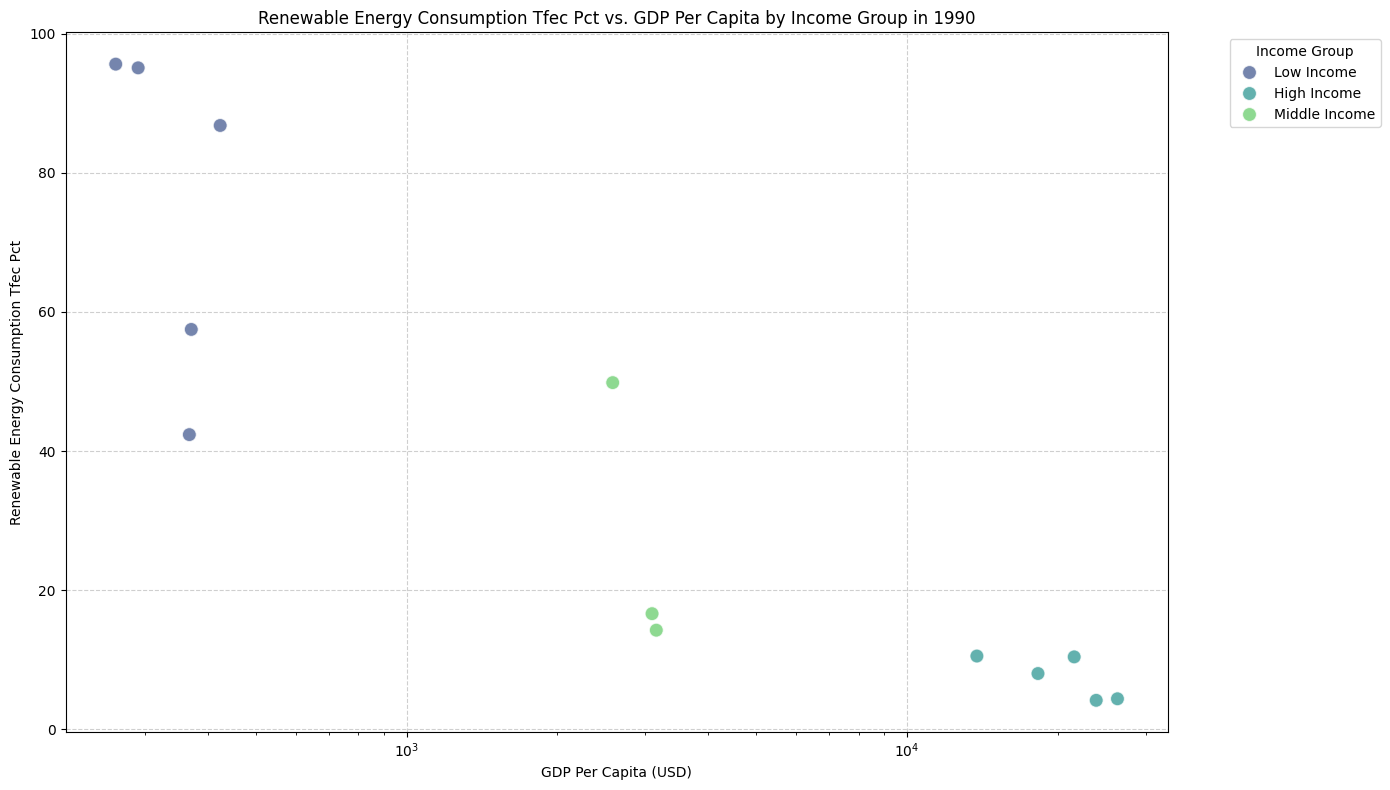

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the energy source that I want to use
energy_source_col = 'renewable_energy_consumption_tfec_pct'

# Filter for the specific year of interest (1990)
data_for_plot_1990 = final_combined_df_with_gdp[
    final_combined_df_with_gdp['yr'] == 1990
].copy()

# Drop rows where GDP or the chosen energy source is NaN for a cleaner
# visualization
data_for_plot_1990.dropna(subset=[energy_source_col, 'gdp_usd', 'income_group'], inplace=True)

# Create the plot for 1990
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_for_plot_1990,
    x='gdp_usd',
    y=energy_source_col,
    hue='income_group',
    s = 100,
    palette='viridis',
    alpha=0.7
)

plt.title(f'{energy_source_col.replace("_", " ").title()} vs. GDP Per Capita by Income Group in 1990')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel(f'{energy_source_col.replace("_", " ").title()}')
plt.xscale('log') # GDP often spans several orders of magnitude, so a log scale is useful
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

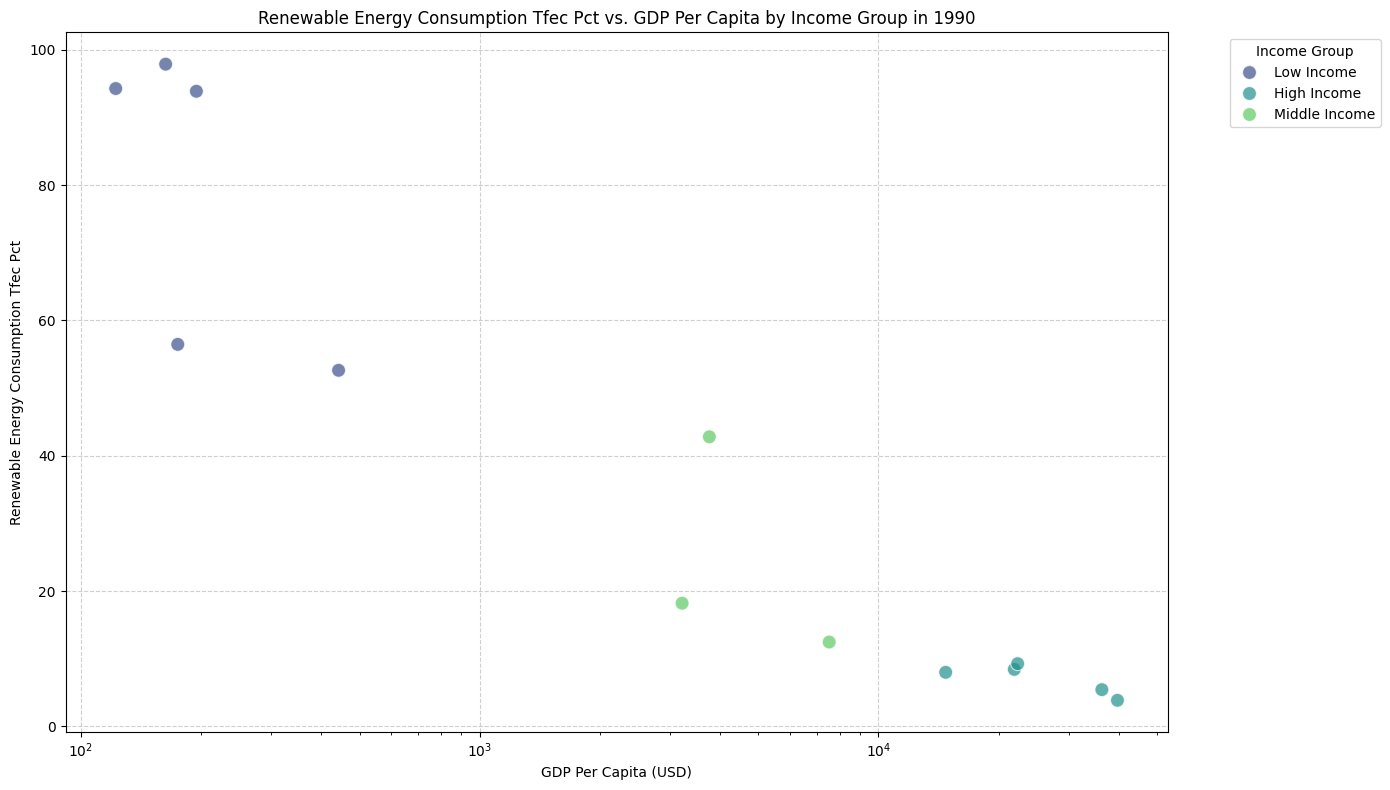

In [122]:
# Select the energy source that I want to use
energy_source_col = 'renewable_energy_consumption_tfec_pct'

# Filter for the specific year of interest (2000)
data_for_plot_1990 = final_combined_df_with_gdp[
    final_combined_df_with_gdp['yr'] == 2000
].copy()

# Drop rows where GDP or the chosen energy source is NaN for a cleaner
# visualization
data_for_plot_1990.dropna(subset=[energy_source_col, 'gdp_usd', 'income_group'], inplace=True)

# Create the plot for 1990
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_for_plot_1990,
    x='gdp_usd',
    y=energy_source_col,
    hue='income_group',
    s = 100,
    palette='viridis',
    alpha=0.7
)

plt.title(f'{energy_source_col.replace("_", " ").title()} vs. GDP Per Capita by Income Group in 1990')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel(f'{energy_source_col.replace("_", " ").title()}')
plt.xscale('log') # GDP often spans several orders of magnitude, so a log scale is useful
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

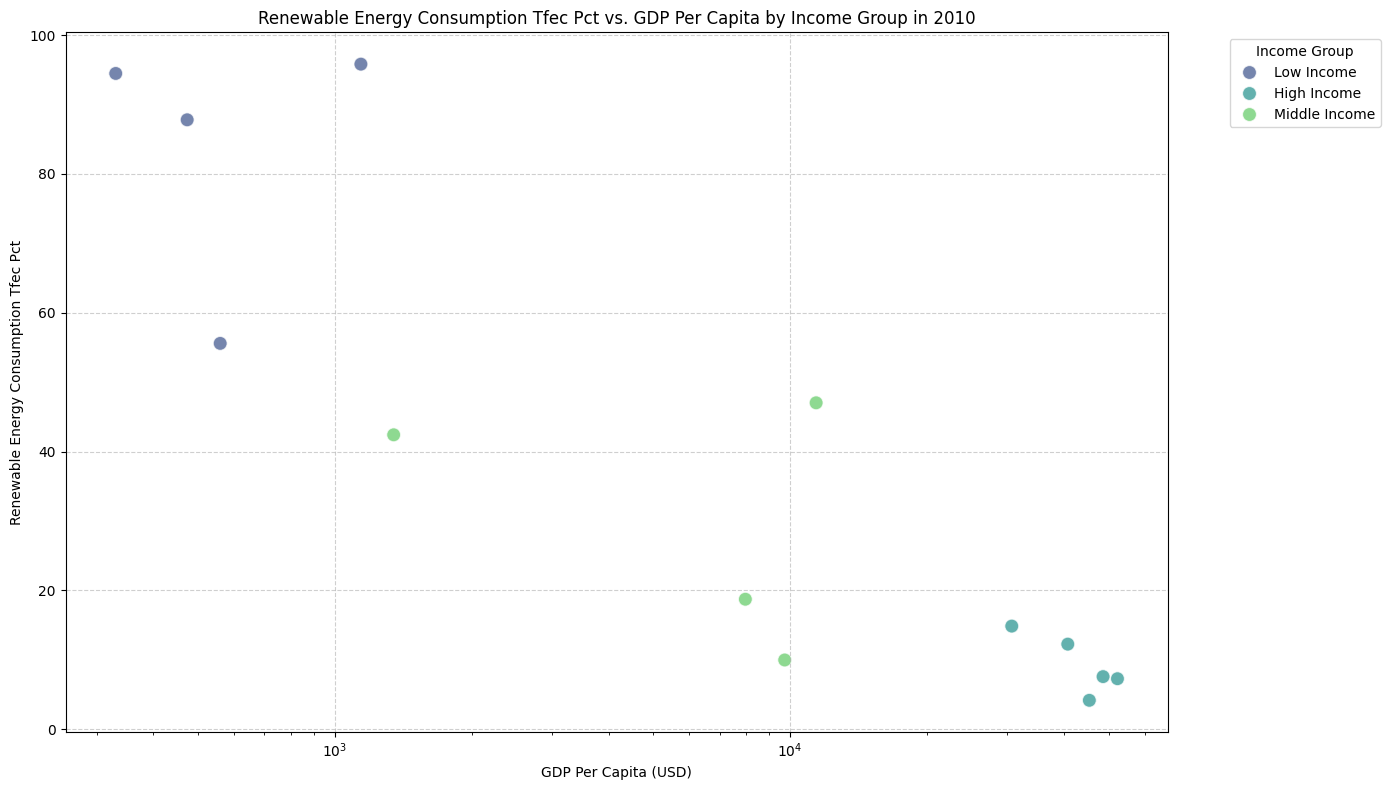

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the specific year of interest (2010)
data_for_plot_2010 = final_combined_df_with_gdp[
    final_combined_df_with_gdp['yr'] == 2010
].copy()

# Drop rows where GDP or the chosen energy source is NaN for cleaner visualization
data_for_plot_2010.dropna(subset=[energy_source_col, 'gdp_usd', 'income_group'], inplace=True)

# Create the plot for 2010
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_for_plot_2010,
    x='gdp_usd',
    y=energy_source_col,
    hue='income_group',
    palette='viridis',
    s = 100,
    alpha=0.7

)

plt.title(f'{energy_source_col.replace("_", " ").title()} vs. GDP Per Capita by Income Group in 2010')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel(f'{energy_source_col.replace("_", " ").title()}')
plt.xscale('log') # GDP often spans several orders of magnitude, so a log scale is useful
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Final Classified Countries

In [207]:
print("### Countries in Final Combined DataFrame by Income Group (Years 1990, 2000, 2010) ###")

for year in [1990, 2000, 2010]:
    print(f"\n--- Year: {year} ---")
    df_year = final_combined_df_with_gdp[final_combined_df_with_gdp['yr'] == year]

    # Get unique countries and their income groups for the current year
    countries_by_income_group = df_year[['income_group', 'country_name']].drop_duplicates().sort_values(by=['income_group', 'country_name'])

    for income_group_name in countries_by_income_group['income_group'].unique():
        countries_in_group = countries_by_income_group[countries_by_income_group['income_group'] == income_group_name]['country_name'].tolist()
        print(f"\n{income_group_name}: ({len(countries_in_group)} countries)")
        for country in countries_in_group:
            print(f"  - {country}")

### Countries in Final Combined DataFrame by Income Group (Years 1990, 2000, 2010) ###

--- Year: 1990 ---

High Income Countries: (8 countries)
  - Andorra
  - Australia
  - Canada
  - France
  - Germany
  - Japan
  - Spain
  - United States

Low Income Countries: (8 countries)
  - Afghanistan
  - Burundi
  - Chad
  - Egypt
  - Ethiopia
  - Madagascar
  - Malawi
  - Niger

Lower-middle-income Countries: (8 countries)
  - Albania
  - Algeria
  - Angola
  - Argentina
  - Belize
  - Bolivia
  - Botswana
  - Turkey

Upper-middle-income Countries: (8 countries)
  - American Samoa
  - Antigua and Barbuda
  - Bahrain
  - Barbados
  - Brazil
  - Czechoslovakia
  - Mexico
  - South Africa

--- Year: 2000 ---

High Income Countries: (8 countries)
  - Andorra
  - Australia
  - Canada
  - France
  - Germany
  - Japan
  - Spain
  - United States

Low Income Countries: (8 countries)
  - Afghanistan
  - Burundi
  - Chad
  - Ethiopia
  - India
  - Indonesia
  - Malawi
  - Niger

Lower-middle-income C

### World Map Visualization of Countries by Income Group (1990, 2000, 2010)


--- Generating map for year: 1990 ---
  DEBUG: 'United States' found in data_for_map before mapping for 1990.
    country_name           income_group
6  United States  High Income Countries
  DEBUG: 'United States of America' found in data_for_map after mapping for 1990.
               country_name           income_group
6  United States of America  High Income Countries
  DEBUG: 'United States of America' MERGED. Income Group: High Income Countries


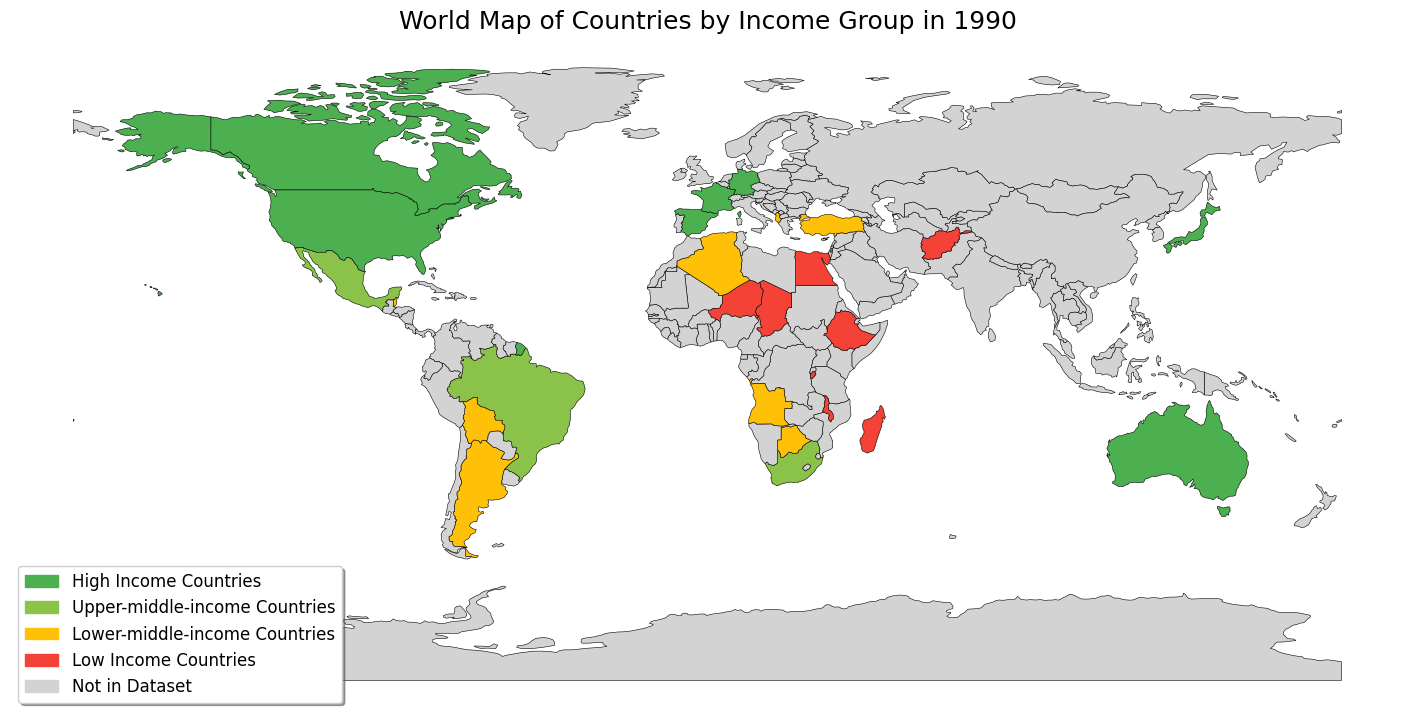


--- Generating map for year: 2000 ---
  DEBUG: 'United States' found in data_for_map before mapping for 2000.
     country_name           income_group
38  United States  High Income Countries
  DEBUG: 'United States of America' found in data_for_map after mapping for 2000.
                country_name           income_group
38  United States of America  High Income Countries
  DEBUG: 'United States of America' MERGED. Income Group: High Income Countries


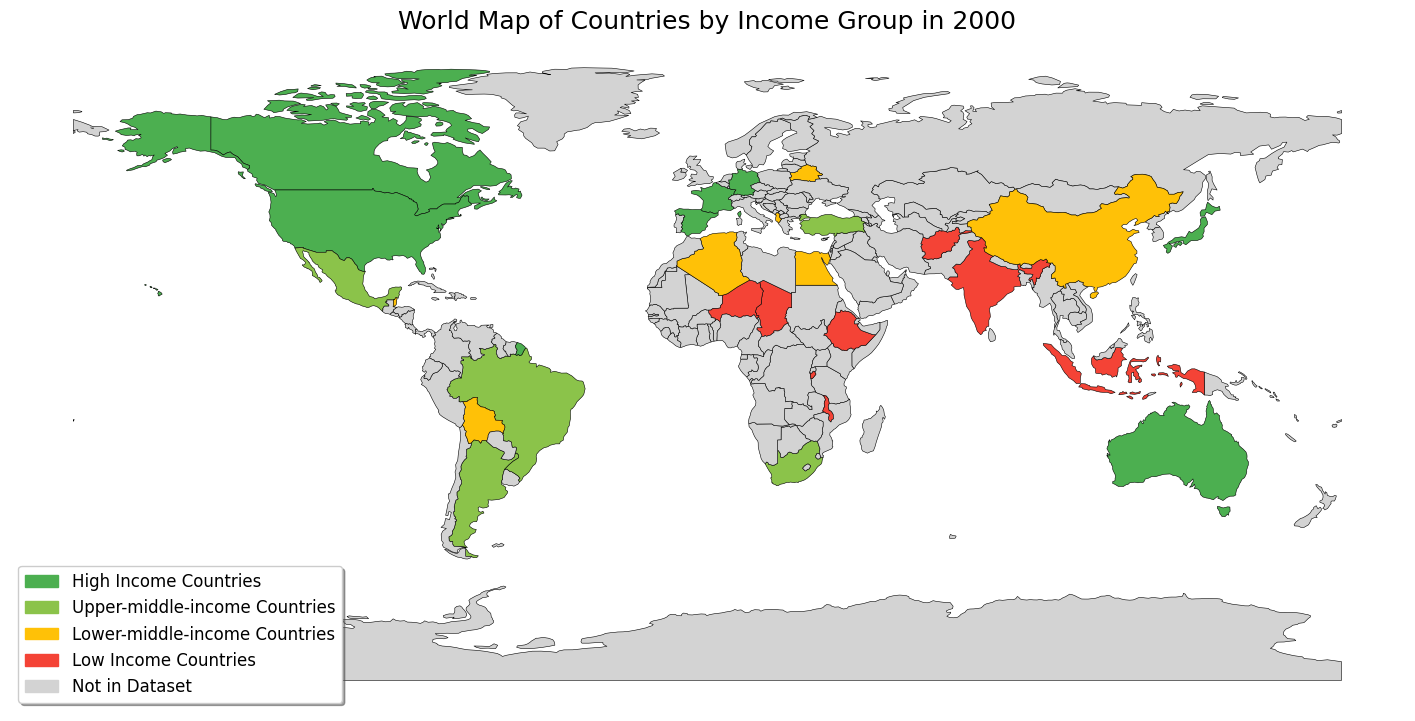


--- Generating map for year: 2010 ---
  DEBUG: 'United States' found in data_for_map before mapping for 2010.
     country_name           income_group
70  United States  High Income Countries
  DEBUG: 'United States of America' found in data_for_map after mapping for 2010.
                country_name           income_group
70  United States of America  High Income Countries
  DEBUG: 'United States of America' MERGED. Income Group: High Income Countries


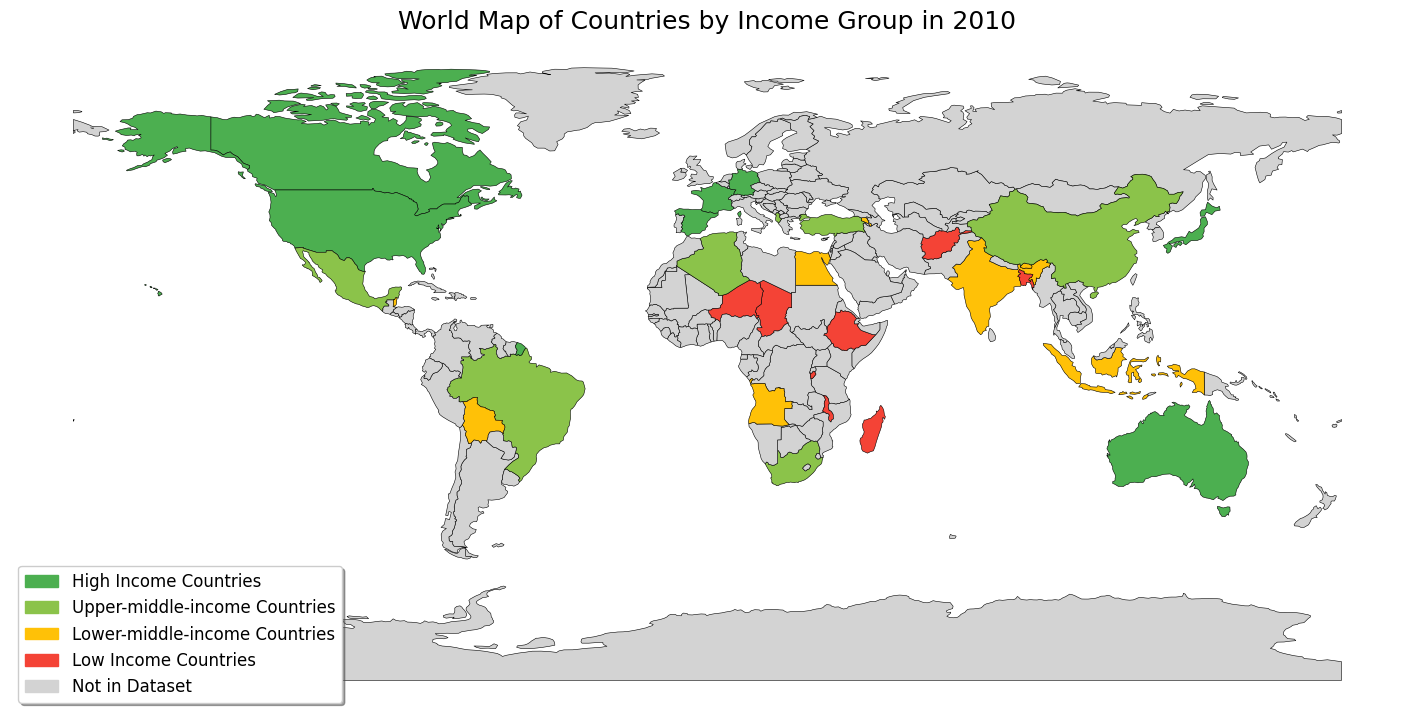

In [214]:
import geopandas as gpd
import matplotlib.pyplot as plt
import requests, zipfile, io
import pandas as pd
import matplotlib.patches as mpatches

# Redefine the income group color map for better clarity
income_color_map = {
    'High Income Countries': '#4CAF50', # Green
    'Upper-middle-income Countries': '#8BC34A', # Light Green
    'Lower-middle-income Countries': '#FFC107', # Amber
    'Low Income Countries': '#F44336' # Red
}

# List of years to generate maps for
years_to_map = [1990, 2000, 2010]

# Download and load Natural Earth shapefile (Admin 0 Countries) if not already done
# (This code block is repeated here for self-containment, but ideally, this would be in a setup cell)
if 'world' not in locals(): # Check if 'world' GeoDataFrame exists
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall("ne_countries")
    world = gpd.read_file("ne_countries/ne_110m_admin_0_countries.shp")

# Define a mapping for country names in our data to match Natural Earth names
# This is crucial for correct merging with the geographical data
geo_country_name_mapping = {
    'United States': 'United States of America',
    'South Korea': 'Republic of Korea',
    'Hong Kong': 'Hong Kong S.A.R.',
    'Egypt': 'Egypt',
    'Russia': 'Russian Federation',
    'Congo, Dem. Rep.': 'Democratic Republic of the Congo',
    'Congo, Rep.': 'Republic of the Congo',
    'Myanmar': 'Myanmar',
    'Slovak Republic': 'Slovakia',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Iran, Islamic Rep.': 'Iran',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Bahamas, The': 'The Bahamas',
    'Timor-Leste': 'East Timor'

}

# Iterate through each year and create a map
for year in years_to_map:
    print(f"\n--- Generating map for year: {year} ---")

    # Filter final_combined_df_with_gdp for the current year and relevant columns
    data_for_map = final_combined_df_with_gdp[
        final_combined_df_with_gdp['yr'] == year
    ][['country_name', 'income_group']].drop_duplicates().copy()

    # DEBUG: Check 'United States' before mapping
    us_before_map = data_for_map[data_for_map['country_name'] == 'United States']
    if not us_before_map.empty:
        print(f"  DEBUG: 'United States' found in data_for_map before mapping for {year}.")
        print(us_before_map)
    else:
        print(f"  DEBUG: 'United States' NOT found in data_for_map before mapping for {year}.")

    # Apply the geographical country name mapping to our data
    data_for_map['country_name'] = data_for_map['country_name'].replace(geo_country_name_mapping)

    # DEBUG: Check 'United States of America' after mapping
    usa_after_map = data_for_map[data_for_map['country_name'] == 'United States of America']
    if not usa_after_map.empty:
        print(f"  DEBUG: 'United States of America' found in data_for_map after mapping for {year}.")
        print(usa_after_map)
    else:
        print(f"  DEBUG: 'United States of America' NOT found in data_for_map after mapping for {year}.")

    # Merge with world map GeoDataFrame
    # Use 'NAME' from world GeoDataFrame and 'country_name' from our data
    merged_map_data = world.merge(data_for_map, how="left", left_on="NAME", right_on="country_name")

    # DEBUG: Check if 'United States of America' merged successfully and has an income_group
    usa_merged = merged_map_data[merged_map_data['NAME'] == 'United States of America']
    if not usa_merged.empty:
        print(f"  DEBUG: 'United States of America' MERGED. Income Group: {usa_merged['income_group'].iloc[0]}")
    else:
        print(f"  DEBUG: 'United States of America' DID NOT MERGE or lost during merge.")

    # Map income_group to colors. Countries not in our data will be 'Not in Dataset'
    merged_map_data['color'] = merged_map_data['income_group'].map(income_color_map).fillna('#D3D3D3') # Grey for 'Not in dataset'

    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    merged_map_data.plot(color=merged_map_data['color'], edgecolor="black", linewidth=0.4, ax=ax)

    ax.set_title(f'World Map of Countries by Income Group in {year}', fontsize=18)
    ax.set_axis_off() # Remove axes

    # Create a custom legend
    legend_patches = []
    for group, color in income_color_map.items():
        legend_patches.append(mpatches.Patch(color=color, label=group))
    legend_patches.append(mpatches.Patch(color='#D3D3D3', label='Not in Dataset'))

    ax.legend(handles=legend_patches, loc='lower left', fontsize=12, frameon=True, fancybox=True, shadow=True)

    plt.show()

In [210]:
print("United States entries in final_combined_df_with_gdp for 1990, 2000, 2010:")
display(final_combined_df_with_gdp[final_combined_df_with_gdp['country_name'] == 'United States'])

print("South American countries entries (e.g., Brazil) in final_combined_df_with_gdp for 1990, 2000, 2010:")
display(final_combined_df_with_gdp[final_combined_df_with_gdp['country_name'] == 'Brazil'])

United States entries in final_combined_df_with_gdp for 1990, 2000, 2010:


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd
6,United States,1990,0.018461,0.125015,0.004010,1.644670,4.175462,49172282.0,High Income Countries,23888.60001
38,United States,2000,0.030316,0.115707,0.107163,1.358611,5.429624,58330543.0,High Income Countries,36329.97026
70,United States,2010,0.523203,0.112890,0.123326,1.442158,7.569218,57172758.0,High Income Countries,48642.63121


South American countries entries (e.g., Brazil) in final_combined_df_with_gdp for 1990, 2000, 2010:


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd
8,Brazil,1990,0.003218,0.0,0.000000,16.492729,49.834827,4269739.000,Upper-middle-income Countries,2581.141874
40,Brazil,2000,0.000113,0.0,0.021720,17.254264,42.794507,5847093.093,Upper-middle-income Countries,3766.548115
72,Brazil,2010,0.082077,0.0,0.190229,15.204742,47.023153,8108121.203,Upper-middle-income Countries,11403.282130


In [211]:
print("Unique country names in 'world' GeoDataFrame relevant to our data:")
display(world[world['NAME'].isin(['United States of America', 'Brazil'])]['NAME'].unique())

Unique country names in 'world' GeoDataFrame relevant to our data:


array(['United States of America', 'Brazil'], dtype=object)